<a href="https://colab.research.google.com/github/EzeRivero/Data-Science-III/blob/main/DS3_Rivero_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Science III: Entrega Final**
##Ezequiel Rivero
###Comisión 77795

#Introducción
El análisis de sentimientos es una de las aplicaciones más potentes del procesamiento de lenguaje natural (NLP). En este proyecto, nos sumergimos en un dataset de reseñas de espectadores extraídas de Rotten Tomatoes. El desafío principal es tomar todo este texto cargado de opiniones, modismos y críticas directas sobre películas y series, y procesarlo para que una máquina pueda entenderlo. La idea es construir un flujo de trabajo que vaya desde la limpieza de estas opiniones y la extracción de su estructura base, hasta el entrenamiento de una red neuronal profunda capaz de clasificar automáticamente si el público aprobó o rechazó lo que vio en pantalla.

El dataset fue tomado desde Kaggle.com, y se utilizará una muestra representativa del total del dataset, para optimizar tiempos de procesamiento.

#Objetivo
El objetivo central es desarrollar un modelo de Deep Learning capaz de leer una reseña cinematográfica y predecir con precisión si el sentimiento del usuario es positivo o negativo. Para lograr esto, se trabajará en la limpieza profunda del texto (eliminando ruido y estandarizando palabras) y se transformará ese lenguaje natural en representaciones numéricas mediante TF-IDF. Finalmente, se busca que la red neuronal aprenda a identificar de manera autónoma los patrones y el vocabulario que definen una buena o mala crítica dentro de la plataforma.

#Contexto Comercial
En la industria del entretenimiento y el streaming, el volumen de feedback generado por los usuarios es masivo y constante. Procesar y clasificar manualmente estas reseñas es técnica y financieramente inviable. Implementar un modelo de análisis de sentimiento automatizado permite a las plataformas cuantificar de manera casi instantánea la recepción del público ante un nuevo lanzamiento. Este tipo de herramientas NLP resulta vital para el negocio: facilita la toma de decisiones ágiles, permite ajustar campañas de marketing en tiempo real, ayuda a identificar problemas con el contenido y alimenta de forma directa los algoritmos de recomendación, mejorando en última instancia la retención del usuario.

#Hipótesis
La hipótesis a demostrar es que, mediante una limpieza exhaustiva del texto y la aplicación de TF-IDF para ponderar la relevancia de los términos, una red neuronal densa logrará identificar patrones de vocabulario y clasificar los sentimientos de las reseñas con un nivel de precisión (Accuracy/F1-Score) significativamente superior al azar. Sin embargo, también se asume que el modelo encontrará su mayor limitación frente al sarcasmo o la ironía, o respuestas con más de un sentido. Al depender del conteo y peso de las palabras pero descartar su orden secuencial, se espera que el modelo pierda ciertos matices contextuales propios de la crítica de cine.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from collections import Counter

# Cargar datos
url = 'https://raw.githubusercontent.com/EzeRivero/Data-Science-III/refs/heads/main/audience_reviews.csv'
df = pd.read_csv(url)

df.head()

,Show,Rating,Review
0,Test,0.0,Test review
1,Loot,2.5,"I love the stars, but the show is riddled with..."
2,Loot,4.5,Great show to watch. It's something that's eas...
3,Loot,0.5,Another Apple tanker crashes into the reef wit...
4,Loot,4.5,"This is such a fun, endearing show. It has a ..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65522 entries, 0 to 65521
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Show    65522 non-null  object 
 1   Rating  65522 non-null  float64
 2   Review  65522 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [4]:
df.describe()

,Rating
count,65522.000000
mean,3.514659
std,1.738253
min,0.000000
25%,2.000000
50%,4.500000
75%,5.000000
max,5.000000


In [7]:
# Crear la variable objetivo (Clasificación Binaria)
# Consideramos reseñas > 3.0 como Positivas (1) y <= 3.0 como Negativas (0)
df['Sentimiento'] = df['Rating'].apply(lambda x: 1 if x > 3.0 else 0)

# Reducir el dataset a 10000 registros manteniendo la proporción de clases (estratificado)
# Usamos train_test_split para tomar la muestra de forma rápida y balanceada
df_sample, _ = train_test_split(df, train_size=10000, stratify=df['Sentimiento'], random_state=42)

# Verificamos
print(df_sample['Sentimiento'].value_counts())

Sentimiento
1    6407
0    3593
Name: count, dtype: int64


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


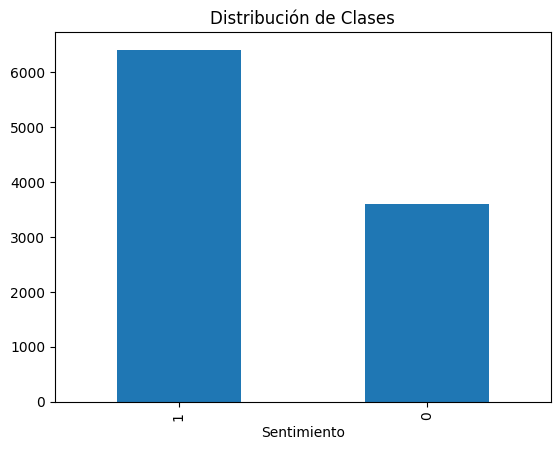

In [10]:
nltk.download('punkt')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")

# --- EDA Básico ---
# Gráfico de distribución de clases
df_sample['Sentimiento'].value_counts().plot(kind='bar', title='Distribución de Clases')
plt.show()

In [16]:
df1 = df.copy()

# Pasamos todo a minúscula. Usamos str() por si llega a haber algún valor numérico o nulo colado.
df1['review_lower'] = df1['Review'].apply(lambda text: str(text).lower())

# Visualizamos el antes y el después
df1[['Review', 'review_lower']].head()

,Review,review_lower
0,Test review,test review
1,"I love the stars, but the show is riddled with...","i love the stars, but the show is riddled with..."
2,Great show to watch. It's something that's eas...,great show to watch. it's something that's eas...
3,Another Apple tanker crashes into the reef wit...,another apple tanker crashes into the reef wit...
4,"This is such a fun, endearing show. It has a ...","this is such a fun, endearing show. it has a ..."


In [17]:
df2 = df1.copy()

def remove_punctuation(text):
    # Esta expresión regular reemplaza cualquier cosa que NO (^) sea una letra de la a-z, número o espacio
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

df2['review_puntuacion'] = df2['review_lower'].apply(remove_punctuation)

df2[['review_lower', 'review_puntuacion']].head()

,review_lower,review_puntuacion
0,test review,test review
1,"i love the stars, but the show is riddled with...",i love the stars but the show is riddled with ...
2,great show to watch. it's something that's eas...,great show to watch its something thats easy a...
3,another apple tanker crashes into the reef wit...,another apple tanker crashes into the reef wit...
4,"this is such a fun, endearing show. it has a ...",this is such a fun endearing show it has a lo...


In [18]:
# Cargamos el modelo pre-entrenado de spaCy para INGLÉS
nlp = spacy.load("en_core_web_sm")

def lematizacion(text):
    doc = nlp(text)
    # Extraemos el lema de cada palabra y las volvemos a unir con un espacio
    return " ".join([token.lemma_ for token in doc])

df3 = df2.copy()
df3['lemas'] = df3['review_puntuacion'].apply(lematizacion)

df3[['review_puntuacion', 'lemas']].head()

,review_puntuacion,lemas
0,test review,test review
1,i love the stars but the show is riddled with ...,I love the star but the show be riddle with cl...
2,great show to watch its something thats easy a...,great show to watch its something that s easy ...
3,another apple tanker crashes into the reef wit...,another apple tanker crash into the reef with ...
4,this is such a fun endearing show it has a lo...,this be such a fun endear show it have a lot...


In [19]:
# Descargamos las herramientas necesarias de NLTK
nltk.download('punkt')
nltk.download('punkt_tab') # Añadido según tu código de referencia

df4 = df3.copy()
df4['review_text_tok'] = df4['lemas'].apply(word_tokenize)

# Verás que ahora la columna tiene listas de palabras: ['this', 'movie', 'is', ...]
df4[['lemas', 'review_text_tok']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,lemas,review_text_tok
0,test review,"[test, review]"
1,I love the star but the show be riddle with cl...,"[I, love, the, star, but, the, show, be, riddl..."
2,great show to watch its something that s easy ...,"[great, show, to, watch, its, something, that,..."
3,another apple tanker crash into the reef with ...,"[another, apple, tanker, crash, into, the, ree..."
4,this be such a fun endear show it have a lot...,"[this, be, such, a, fun, endear, show, it, hav..."


In [20]:
nltk.download('stopwords')

# Cargamos la lista de stopwords en INGLÉS
stop_words = set(stopwords.words('english'))

df5 = df4.copy()

# Recorremos la lista de tokens y nos quedamos solo con las palabras que NO están en los stopwords
df5['review_sin_stopwords'] = df5['review_text_tok'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

df5[['review_text_tok', 'review_sin_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


NameError: name 'stopwords' is not defined